In [2]:
import pandas as pd

import dowhy
import networkx as nx

import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", None)

In [17]:
G = nx.DiGraph()

In [18]:
nodes = [
    "polAffectiveIndex",   # Affective Polarization
    "matchTreatment",      # Match Treatment
    "genderF",             # Gender
    "partyAllF",           # Party
    "trumpF",              # Trump
    "ideologyF",
    "ageWM",
    "thermo_DiffWM",             # Feelings thermometer diff
    "empathyDifficult_DiffWM"            # Underlying Ideology (placeholder)
]

In [19]:
edges = [
    ("matchTreatment", "polAffectiveIndex"),
    ("trumpF", "polAffectiveIndex"),
    ("ideologyF", "partyAllF"),
    ("ideologyF", "trumpF"),
    ("partyAllF", "trumpF"),
    ("ideologyF", "polAffectiveIndex"),
    ("ageWM", "polAffectiveIndex"),
     # Edges replicated for both Thermo and Empathy nodes
    ("thermo_DiffWM", "polAffectiveIndex"),
    ("empathyDifficult_DiffWM", "polAffectiveIndex"),

    ("trumpF", "thermo_DiffWM"),
    ("trumpF", "empathyDifficult_DiffWM"),

    ("partyAllF", "thermo_DiffWM"),
    ("partyAllF", "empathyDifficult_DiffWM"),

    ("ideologyF", "thermo_DiffWM"),
    ("ideologyF", "empathyDifficult_DiffWM"),

    ("genderF", "thermo_DiffWM"),
    ("genderF", "empathyDifficult_DiffWM"),
]

In [20]:
G.add_edges_from(edges)

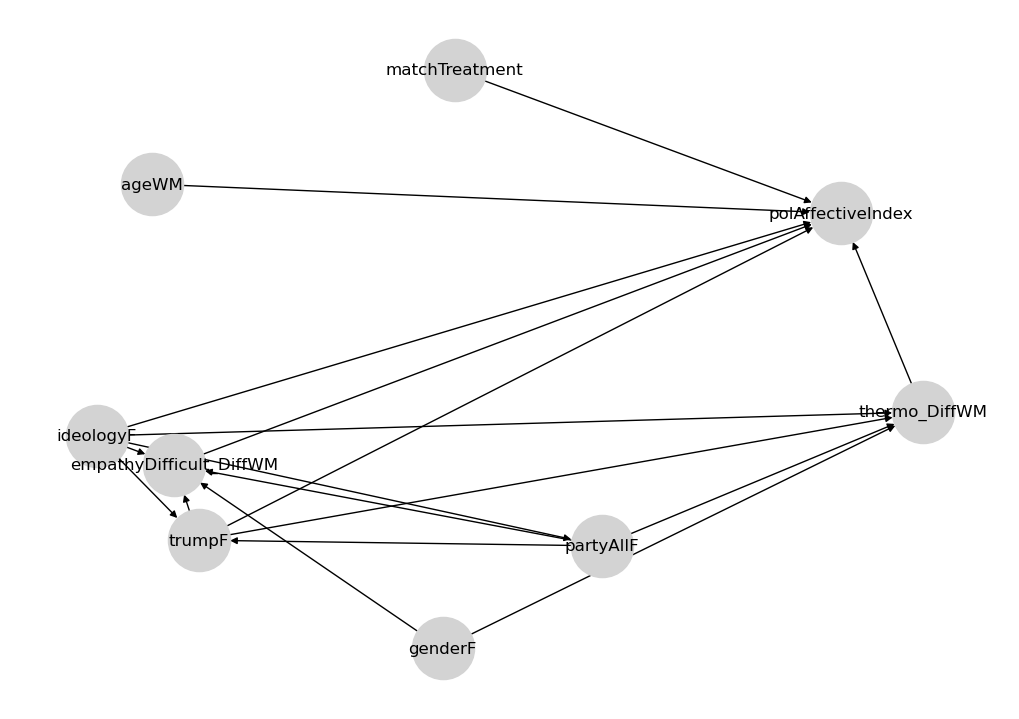

In [21]:
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42)  # or manually define positions to match TikZ
nx.draw(G, pos, with_labels=True, node_size=2000, node_color="lightgray", arrows=True)
plt.show()

In [7]:
survey = pd.read_csv(r"C:\Users\Peter\OneDrive\Desktop\Code and Projects\ECO1465\clean survey.csv")

In [8]:
survey

,Unnamed: 0,ResponseId,treatment,matchTreatment,treatIdeo,control,potentialText,primaryOutlets,comply,newLikesNum,...,F_slant_Dem,F_ideology,F_echoChamber,F_whoWillWin,F_vote,F_modifiedViews,F_withoutLastControl,F_startPOSIX,weightPers,weightPol
0,1,R_0006zeOG7m4r5bX,Liberal,Counter,treatLIdeoC,False,"c(""FoxNews"", ""HuffPost"", ""MSNBC"", ""NationalRev...",True,True,4,...,-3.0,0.0,1.0,-1.0,999.0,1.0,True,2018-04-23 13:44:25,0.000252,0.000268
1,2,R_000QuLyZsff11wl,Control,Control,control,True,"c(""FoxNews"", ""HuffPost"", ""MSNBC"", ""NationalRev...",True,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,True,2018-04-19 11:59:13,0.000094,0.000085
2,3,R_006vNO79PBEQJK9,Liberal,Counter,treatLIdeoC,False,"c(""HuffPost"", ""MSNBC"", ""NationalReview"", ""Slat...",False,False,0,...,-3.0,2.0,2.0,1.0,1.0,0.0,True,2018-04-19 13:48:09,0.000132,0.000123
3,4,R_00QUYdXn0LIx6sF,Control,Control,control,True,"c(""FoxNews"", ""HuffPost"", ""NationalReview"", ""Sa...",False,NaN,0,...,-2.0,-2.0,3.0,-1.0,-1.0,0.0,True,2018-04-25 20:11:53,0.000059,0.000062
4,5,R_00VWiXSyP4IFidX,Control,Control,control,True,"c(""FoxNews"", ""MSNBC"", ""NationalReview"", ""Salon...",False,NaN,0,...,-3.0,0.0,3.0,-1.0,-1.0,1.0,True,2018-04-25 16:41:36,0.000059,0.000062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17630,17631,R_zf2l1Hew4SGGGpr,Conservative,Pro,treatCIdeoC,False,"c(""DailyCaller"", ""HuffPost"", ""MSNBC"", ""Nationa...",False,False,0,...,-2.0,2.0,2.0,1.0,1.0,0.0,True,2018-05-20 23:01:55,0.000264,0.000246
17631,17632,R_zfeiEbwrxA57jrP,Control,Control,control,True,"c(""FoxNews"", ""HuffPost"", ""MSNBC"", ""NationalRev...",True,NaN,0,...,-2.0,-3.0,3.0,-1.0,-1.0,0.0,True,2018-05-20 09:57:02,0.000061,0.000063
17632,17633,R_zfiOvlmPfCMWNRn,Conservative,Counter,treatCIdeoL,False,"c(""FoxNews"", ""HuffPost"", ""MSNBC"", ""NationalRev...",True,False,0,...,-1.0,0.0,2.0,999.0,-1.0,0.0,True,2018-05-16 18:23:22,0.000147,0.000155
17633,17634,R_zfj2X1JcX4Yc2Qx,Control,Control,control,True,"c(""FoxNews"", ""HuffPost"", ""MSNBC"", ""NationalRev...",True,NaN,0,...,-2.0,-3.0,2.0,-1.0,-1.0,1.0,True,2018-04-19 12:15:59,0.000061,0.000052


In [9]:
survey = survey.dropna(subset=["polAffectiveIndex"])
survey

,Unnamed: 0,ResponseId,treatment,matchTreatment,treatIdeo,control,potentialText,primaryOutlets,comply,newLikesNum,...,F_slant_Dem,F_ideology,F_echoChamber,F_whoWillWin,F_vote,F_modifiedViews,F_withoutLastControl,F_startPOSIX,weightPers,weightPol
0,1,R_0006zeOG7m4r5bX,Liberal,Counter,treatLIdeoC,False,"c(""FoxNews"", ""HuffPost"", ""MSNBC"", ""NationalRev...",True,True,4,...,-3.0,0.0,1.0,-1.0,999.0,1.0,True,2018-04-23 13:44:25,0.000252,0.000268
2,3,R_006vNO79PBEQJK9,Liberal,Counter,treatLIdeoC,False,"c(""HuffPost"", ""MSNBC"", ""NationalReview"", ""Slat...",False,False,0,...,-3.0,2.0,2.0,1.0,1.0,0.0,True,2018-04-19 13:48:09,0.000132,0.000123
3,4,R_00QUYdXn0LIx6sF,Control,Control,control,True,"c(""FoxNews"", ""HuffPost"", ""NationalReview"", ""Sa...",False,NaN,0,...,-2.0,-2.0,3.0,-1.0,-1.0,0.0,True,2018-04-25 20:11:53,0.000059,0.000062
4,5,R_00VWiXSyP4IFidX,Control,Control,control,True,"c(""FoxNews"", ""MSNBC"", ""NationalReview"", ""Salon...",False,NaN,0,...,-3.0,0.0,3.0,-1.0,-1.0,1.0,True,2018-04-25 16:41:36,0.000059,0.000062
5,6,R_01cK08xkLSosPJf,Conservative,Counter,treatCIdeoL,False,"c(""FoxNews"", ""HuffPost"", ""MSNBC"", ""NationalRev...",True,True,1,...,-2.0,-2.0,3.0,-1.0,-1.0,0.0,True,2018-04-26 11:35:44,0.000069,0.000071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17630,17631,R_zf2l1Hew4SGGGpr,Conservative,Pro,treatCIdeoC,False,"c(""DailyCaller"", ""HuffPost"", ""MSNBC"", ""Nationa...",False,False,0,...,-2.0,2.0,2.0,1.0,1.0,0.0,True,2018-05-20 23:01:55,0.000264,0.000246
17631,17632,R_zfeiEbwrxA57jrP,Control,Control,control,True,"c(""FoxNews"", ""HuffPost"", ""MSNBC"", ""NationalRev...",True,NaN,0,...,-2.0,-3.0,3.0,-1.0,-1.0,0.0,True,2018-05-20 09:57:02,0.000061,0.000063
17632,17633,R_zfiOvlmPfCMWNRn,Conservative,Counter,treatCIdeoL,False,"c(""FoxNews"", ""HuffPost"", ""MSNBC"", ""NationalRev...",True,False,0,...,-1.0,0.0,2.0,999.0,-1.0,0.0,True,2018-05-16 18:23:22,0.000147,0.000155
17633,17634,R_zfj2X1JcX4Yc2Qx,Control,Control,control,True,"c(""FoxNews"", ""HuffPost"", ""MSNBC"", ""NationalRev...",True,NaN,0,...,-2.0,-3.0,2.0,-1.0,-1.0,1.0,True,2018-04-19 12:15:59,0.000061,0.000052


In [ ]:
X = survey[["ideologyF", "partyAllF", "trumpF", "genderF", "ageWM", 
            "matchTreatment", "thermo_DiffWM", "empathyDifficult_DiffWM"]]
Y = survey["polAffectiveIndex"]

In [55]:
pd.concat([Y,X], axis = 1)

,polAffectiveIndex,ideologyF,partyAllF,trumpF,genderF,ageWM,ageSqWM,ageHave,ideoLeaningF,matchTreatment,thermo_DiffWM,thermo_DiffHave,empathyDifficult_DiffHave,empathyDifficult_DiffWM
0,-1.593928,4. Moderate; middle of the road,Republican,Strongly disapprove,female,40,1600,True,conservativeIdeo,Counter,0,True,True,-1
2,-0.328759,6. Conservative,Lean Republican,Strongly approve,male,69,4761,True,conservativeIdeo,Counter,46,True,True,0
3,-0.206452,2. Liberal,Strong Democrat,Strongly disapprove,female,59,3481,True,liberalIdeo,Control,87,True,True,2
4,0.657809,2. Liberal,Strong Democrat,Strongly disapprove,male,43,1849,True,liberalIdeo,Control,80,True,True,3
5,0.203449,2. Liberal,Strong Democrat,Strongly disapprove,female,31,961,True,liberalIdeo,Counter,89,True,True,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17630,-1.416956,6. Conservative,Lean Republican,Strongly approve,male,49,2401,True,conservativeIdeo,Pro,5,True,False,0
17631,1.156575,1. Extremely liberal,Strong Democrat,Strongly disapprove,female,42,1764,True,liberalIdeo,Control,69,True,True,4
17632,-1.053538,2. Liberal,Democrat,Strongly disapprove,female,30,900,True,liberalIdeo,Counter,34,True,True,1
17633,0.013279,2. Liberal,Lean Democrat,Strongly disapprove,female,27,729,True,liberalIdeo,Control,41,True,True,2


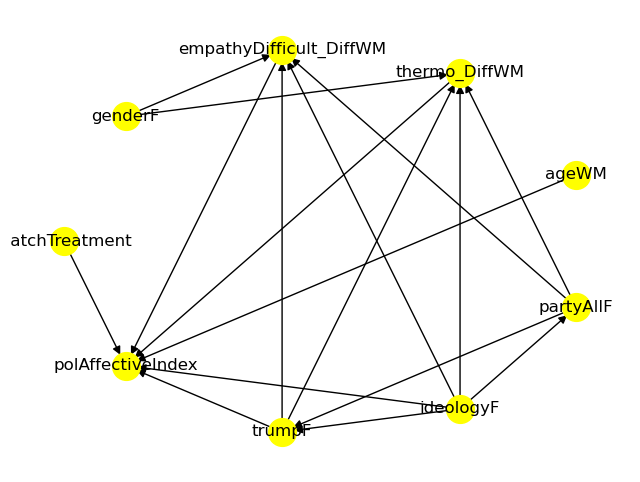

In [54]:
model = dowhy.CausalModel(data=survey, treatment="matchTreatment", 
                          outcome="polAffectiveIndex", graph="\n".join(nx.generate_gml(G)))
model.view_model()

In [52]:
estimand = model.identify_effect()
print(estimand)

Estimand type: nonparametric-ate

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                              
─────────────────(E[polAffectiveIndex])
d[matchTreatment]                      
Estimand assumption 1, Unconfoundedness: If U→{matchTreatment} and U→polAffectiveIndex then P(polAffectiveIndex|matchTreatment,,U) = P(polAffectiveIndex|matchTreatment,)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



In [57]:
estimate = model.estimate_effect(identified_estimand=estimand,
                                 method_name="backdoor.linear_regression")
print(estimate)

linear_regression
{'control_value': 0, 'treatment_value': 1, 'test_significance': None, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': ['empathyDifficult_DiffWM', 'thermo_DiffWM', 'genderF', 'trumpF', 'partyAllF', 'ideologyF', 'ageWM']}


ValueError: shapes (16896,73) and (49,) not aligned: 73 (dim 1) != 49 (dim 0)

In [ ]:
refute_subset = model.refute_estimate(estimand=estimand, estimate=estimate, 
                                      method_name="random_common_cause", subset_fraction=0.4)

ValueError: Aborting refutation! No valid estimate is provided.